# 💻 Laptop Dataset — Data Cleaning & Visualization

**Dataset:** `laptop.xlsx` — 893 laptop listings with specs, prices, and ratings  
**Goal:** Clean raw data → explore patterns → tell a data-driven story  

---
### Table of Contents
1. [Import Libraries](#1)
2. [Load & Inspect Data](#2)
3. [Data Cleaning](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Visualizations](#5)
6. [Key Insights](#6)

## 1. Import Libraries <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## 2. Load & Inspect Data <a id='2'></a>

In [2]:
df = pd.read_excel('laptop.xlsx')
print(f'Shape: {df.shape}')
df.head()

Shape: (893, 18)


,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920,1080,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920,1080,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920,1080,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240,1400,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560,1600,Mac OS,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    str    
 3   name               893 non-null    str    
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    str    
 7   CPU                893 non-null    str    
 8   Ram                893 non-null    str    
 9   Ram_type           893 non-null    str    
 10  ROM                893 non-null    str    
 11  ROM_type           893 non-null    str    
 12  GPU                893 non-null    str    
 13  display_size       893 non-null    float64
 14  resolution_width   893 non-null    int64  
 15  resolution_height  893 non-null    int64  
 16  OS                 893 non-null    st

In [4]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,price,spec_rating,display_size,resolution_width,resolution_height,warranty
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000
mean,467.135498,521.382979,79907.409854,69.379026,15.173751,2035.393057,1218.324748,1.079507
std,270.209769,299.916605,60880.043823,5.541555,0.939095,426.076009,326.756883,0.326956
min,0.000000,0.000000,9999.000000,60.000000,11.600000,1080.000000,768.000000,0.000000
25%,235.000000,265.000000,44500.000000,66.000000,14.000000,1920.000000,1080.000000,1.000000
50%,467.000000,531.000000,61990.000000,69.323529,15.600000,1920.000000,1080.000000,1.000000
75%,702.000000,784.000000,90990.000000,71.000000,15.600000,1920.000000,1200.000000,1.000000
max,930.000000,1019.000000,450039.000000,89.000000,18.000000,3840.000000,3456.000000,3.000000


In [5]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
Unnamed: 0.1,0,0.0
Unnamed: 0,0,0.0
brand,0,0.0
name,0,0.0
price,0,0.0
spec_rating,0,0.0
processor,0,0.0
CPU,0,0.0
Ram,0,0.0
Ram_type,0,0.0


In [6]:
# Duplicate check
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


## 3. Data Cleaning <a id='3'></a>

Issues identified:
- Redundant index columns (`Unnamed: 0`, `Unnamed: 0.1`)
- `OS` column has dirty/inconsistent values (extra spaces, tabs, variants)
- `Ram` and `ROM` are strings — need numeric extraction
- `warranty` = 0 is unusual — treat as missing/unknown
- Price outliers need investigation

In [7]:
# ── Step 1: Drop redundant index columns ──────────────────────────────────────
df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
print('Dropped redundant index columns ✅')
print('Remaining columns:', list(df.columns))

Dropped redundant index columns ✅
Remaining columns: ['brand', 'name', 'price', 'spec_rating', 'processor', 'CPU', 'Ram', 'Ram_type', 'ROM', 'ROM_type', 'GPU', 'display_size', 'resolution_width', 'resolution_height', 'OS', 'warranty']


In [8]:
# ── Step 2: Clean OS column ───────────────────────────────────────────────────
print('Raw OS values:')
print(df['OS'].value_counts().to_string())

Raw OS values:
OS
Windows 11 OS         782
Windows 10 OS          28
DOS OS                 18
Windows 11  OS         15
Mac OS                 12
Windows 10  OS         10
Chrome OS              10
Windows OS              9
Ubuntu OS               2
DOS 3.0 OS              2
Mac 10.15.3\t OS        2
Android 11 OS           1
Mac Catalina OS         1
Mac High Sierra OS      1


In [9]:
def clean_os(val):
    """Normalize OS strings to canonical categories."""
    val = str(val).strip().lower().replace('\t', ' ')
    if 'windows 11' in val:  return 'Windows 11'
    if 'windows 10' in val:  return 'Windows 10'
    if 'windows' in val:     return 'Windows (Other)'
    if 'mac' in val:         return 'macOS'
    if 'android' in val:     return 'Android'
    if 'chrome' in val:      return 'Chrome OS'
    if 'ubuntu' in val:      return 'Ubuntu'
    if 'dos' in val:         return 'DOS'
    return 'Other'

df['OS_clean'] = df['OS'].apply(clean_os)
print('Cleaned OS values:')
print(df['OS_clean'].value_counts())

Cleaned OS values:
OS_clean
Windows 11         797
Windows 10          38
DOS                 20
macOS               16
Chrome OS           10
Windows (Other)      9
Ubuntu               2
Android              1
Name: count, dtype: int64


In [10]:
# ── Step 3: Extract numeric Ram and ROM ───────────────────────────────────────
def extract_gb(val):
    """Extract numeric GB value; convert TB to GB."""
    val = str(val).upper().strip()
    if 'TB' in val:
        return int(val.replace('TB', '').strip()) * 1024
    return int(val.replace('GB', '').strip())

df['Ram_GB']  = df['Ram'].apply(extract_gb)
df['ROM_GB']  = df['ROM'].apply(extract_gb)

print('Ram_GB unique values:', sorted(df['Ram_GB'].unique()))
print('ROM_GB unique values:', sorted(df['ROM_GB'].unique()))

Ram_GB unique values: [np.int64(2), np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(32), np.int64(64)]
ROM_GB unique values: [np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512), np.int64(1024), np.int64(2048)]


In [11]:
# ── Step 4: Handle outliers — Price ───────────────────────────────────────────
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f'Price range: ₹{df["price"].min():,} – ₹{df["price"].max():,}')
print(f'IQR bounds: ₹{lower_bound:,.0f} – ₹{upper_bound:,.0f}')
print(f'Outliers detected: {len(outliers)} rows')

# Flag outliers instead of dropping — they are real premium laptops
df['price_outlier'] = (df['price'] < lower_bound) | (df['price'] > upper_bound)

Price range: ₹9,999 – ₹450,039
IQR bounds: ₹-25,235 – ₹160,725
Outliers detected: 71 rows


In [12]:
# ── Step 5: Handle warranty = 0 ───────────────────────────────────────────────
print('Warranty distribution before:')
print(df['warranty'].value_counts())

# Replace 0-warranty with NaN (unknown) and fill with median
df['warranty'] = df['warranty'].replace(0, np.nan)
df['warranty'].fillna(df['warranty'].median(), inplace=True)
print('\nWarranty distribution after (0 → median):')
print(df['warranty'].value_counts())

Warranty distribution before:
warranty
1    819
2     59
3      9
0      6
Name: count, dtype: int64

Warranty distribution after (0 → median):
warranty
1.0    819
2.0     59
3.0      9
Name: count, dtype: int64


In [13]:
# ── Step 6: Final cleaned dataset overview ────────────────────────────────────
print(f'Final shape: {df.shape}')
print(f'No remaining nulls: {df.isnull().sum().sum() == 0}')
df.head()

Final shape: (893, 20)
No remaining nulls: False


,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty,OS_clean,Ram_GB,ROM_GB,price_outlier
0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920,1080,Windows 11 OS,1.0,Windows 11,8,512,False
1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920,1080,Windows 11 OS,1.0,Windows 11,8,512,False
2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920,1080,Windows 11 OS,1.0,Windows 11,8,512,False
3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240,1400,Windows 11 OS,1.0,Windows 11,16,512,False
4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560,1600,Mac OS,1.0,macOS,8,256,False


## 4. Exploratory Data Analysis (EDA) <a id='4'></a>

In [14]:
# Brand distribution
print('Top 10 Brands by listing count:')
print(df['brand'].value_counts().head(10))

Top 10 Brands by listing count:
brand
HP         186
Lenovo     169
Asus       157
Dell       107
Acer        84
MSI         65
Samsung     28
Apple       16
Infinix     15
LG           9
Name: count, dtype: int64


In [15]:
# Price by brand (top 10 brands)
top_brands = df['brand'].value_counts().head(10).index
df[df['brand'].isin(top_brands)].groupby('brand')['price'].describe().sort_values('mean', ascending=False).round(0)

,count,mean,std,min,25%,50%,75%,max
brand,,,,,,,,
Apple,16.0,174231.0,74456.0,69990.0,112242.0,172445.0,220743.0,309490.0
LG,9.0,128618.0,38773.0,78299.0,98999.0,127000.0,146990.0,205000.0
Samsung,28.0,117512.0,56200.0,49990.0,74840.0,106490.0,151490.0,281990.0
MSI,65.0,100850.0,82638.0,33990.0,53990.0,79990.0,97990.0,420000.0
Dell,107.0,91151.0,71746.0,31490.0,50040.0,67990.0,93490.0,450039.0
HP,186.0,80872.0,64263.0,15990.0,43247.0,59490.0,91315.0,415000.0
Asus,157.0,75774.0,51192.0,10990.0,47990.0,65990.0,89990.0,429990.0
Lenovo,169.0,70061.0,49888.0,18990.0,41190.0,57799.0,76890.0,399999.0
Acer,84.0,58651.0,34484.0,13990.0,35740.0,50490.0,65242.0,179880.0


In [16]:
# Correlation matrix
numeric_cols = ['price', 'spec_rating', 'Ram_GB', 'ROM_GB', 'display_size',
                'resolution_width', 'resolution_height', 'warranty']
df[numeric_cols].corr().round(2)

,price,spec_rating,Ram_GB,ROM_GB,display_size,resolution_width,resolution_height,warranty
price,1.00,0.55,0.74,0.62,0.23,0.59,0.60,0.14
spec_rating,0.55,1.00,0.40,0.40,0.27,0.34,0.33,0.11
Ram_GB,0.74,0.40,1.00,0.60,0.19,0.47,0.43,0.14
ROM_GB,0.62,0.40,0.60,1.00,0.25,0.43,0.36,0.12
display_size,0.23,0.27,0.19,0.25,1.00,0.13,0.03,0.03
resolution_width,0.59,0.34,0.47,0.43,0.13,1.00,0.73,0.05
resolution_height,0.60,0.33,0.43,0.36,0.03,0.73,1.00,0.02
warranty,0.14,0.11,0.14,0.12,0.03,0.05,0.02,1.00


## 5. Visualizations <a id='5'></a>

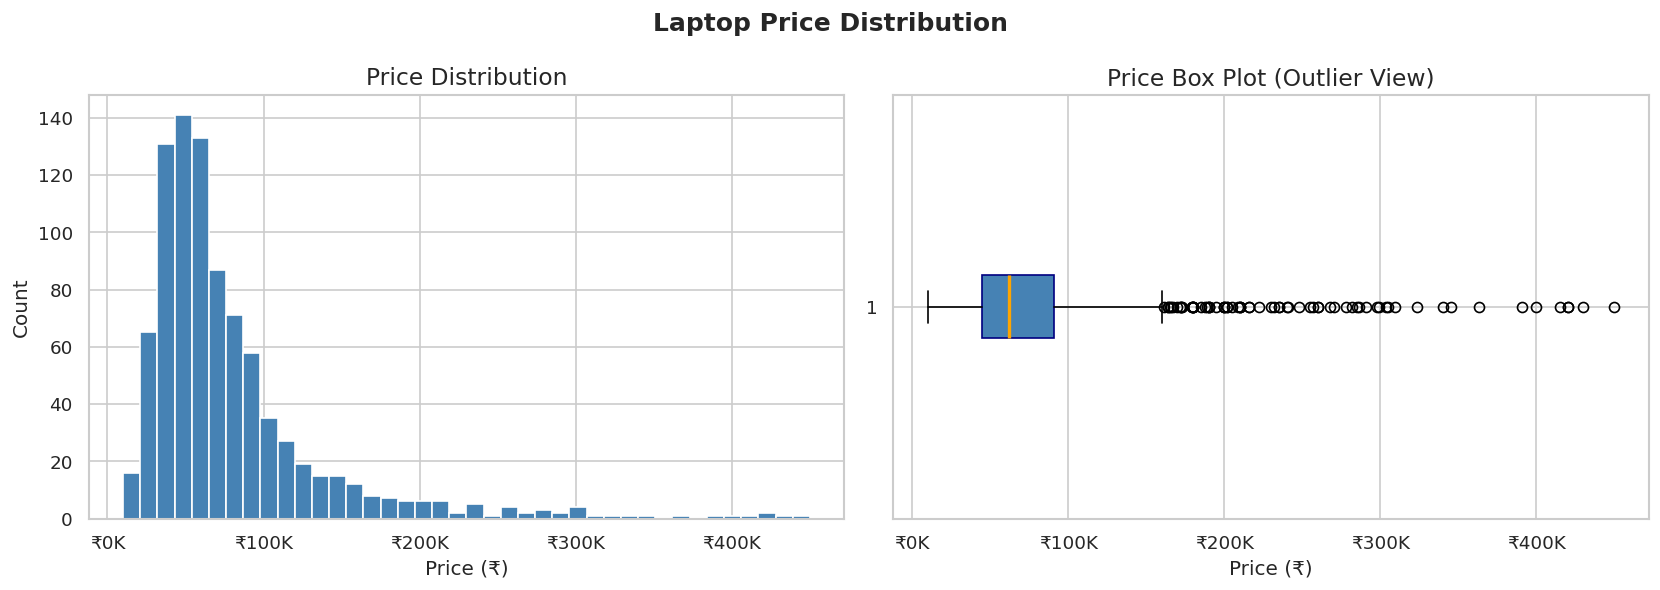

Saved: chart1_price_distribution.png


In [17]:
# ── Chart 1: Price Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

axes[1].boxplot(df['price'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='orange', linewidth=2))
axes[1].set_title('Price Box Plot (Outlier View)')
axes[1].set_xlabel('Price (₹)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.suptitle('Laptop Price Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_price_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: chart1_price_distribution.png')

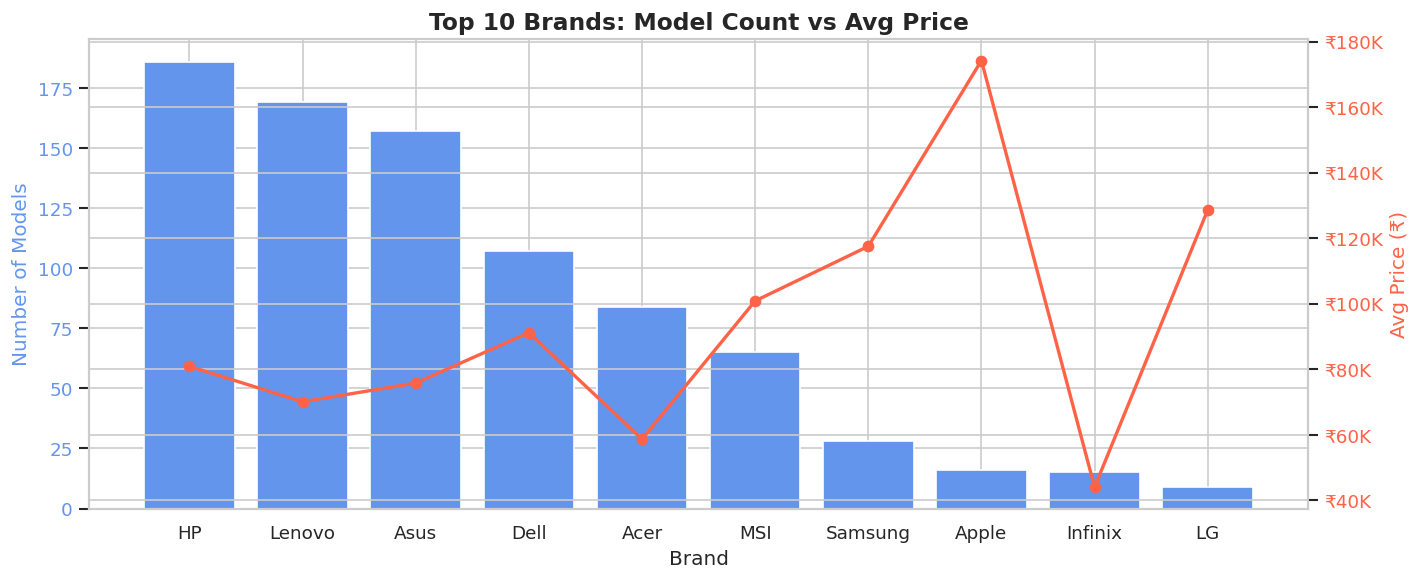

Saved: chart2_brand_count_price.png


In [18]:
# ── Chart 2: Top 10 Brands by Count & Avg Price ───────────────────────────────
top10 = df[df['brand'].isin(top_brands)]
brand_stats = top10.groupby('brand').agg(
    count=('brand', 'count'),
    avg_price=('price', 'mean')
).sort_values('count', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(brand_stats.index, brand_stats['count'], color='cornflowerblue', label='Count')
ax1.set_ylabel('Number of Models', color='cornflowerblue')
ax1.tick_params(axis='y', labelcolor='cornflowerblue')
ax1.set_xlabel('Brand')

ax2 = ax1.twinx()
ax2.plot(brand_stats.index, brand_stats['avg_price'], 'o-', color='tomato', linewidth=2, label='Avg Price')
ax2.set_ylabel('Avg Price (₹)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.title('Top 10 Brands: Model Count vs Avg Price', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('chart2_brand_count_price.png', bbox_inches='tight')
plt.show()
print('Saved: chart2_brand_count_price.png')

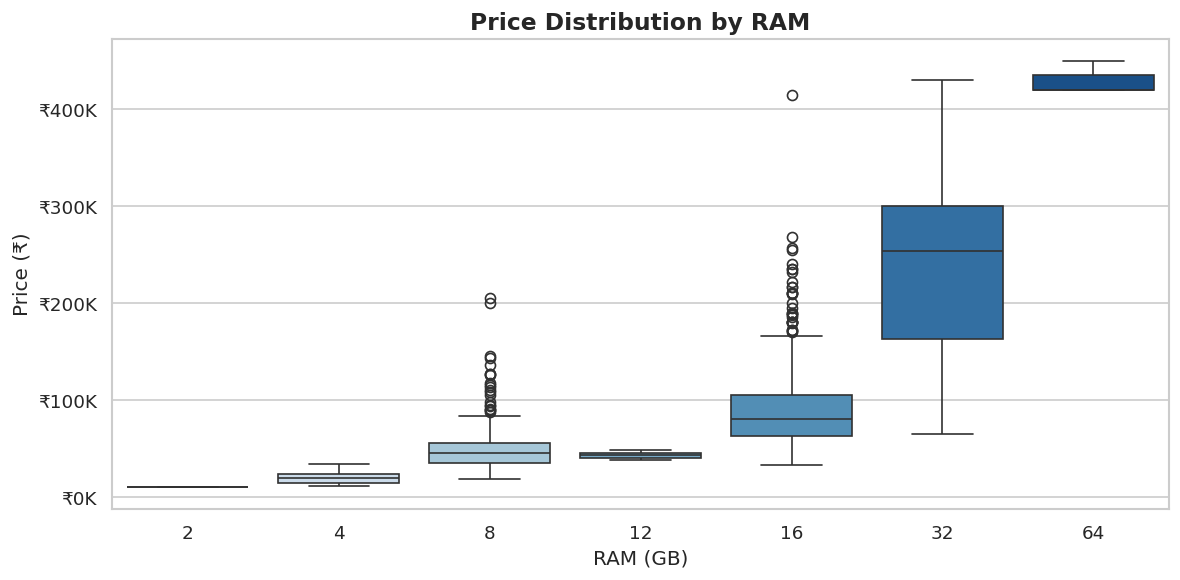

Saved: chart3_price_by_ram.png


In [19]:
# ── Chart 3: Price by RAM ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ram_order = sorted(df['Ram_GB'].unique())
sns.boxplot(data=df, x='Ram_GB', y='price', order=ram_order,
            palette='Blues', ax=ax)
ax.set_title('Price Distribution by RAM', fontsize=14, fontweight='bold')
ax.set_xlabel('RAM (GB)')
ax.set_ylabel('Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('chart3_price_by_ram.png', bbox_inches='tight')
plt.show()
print('Saved: chart3_price_by_ram.png')

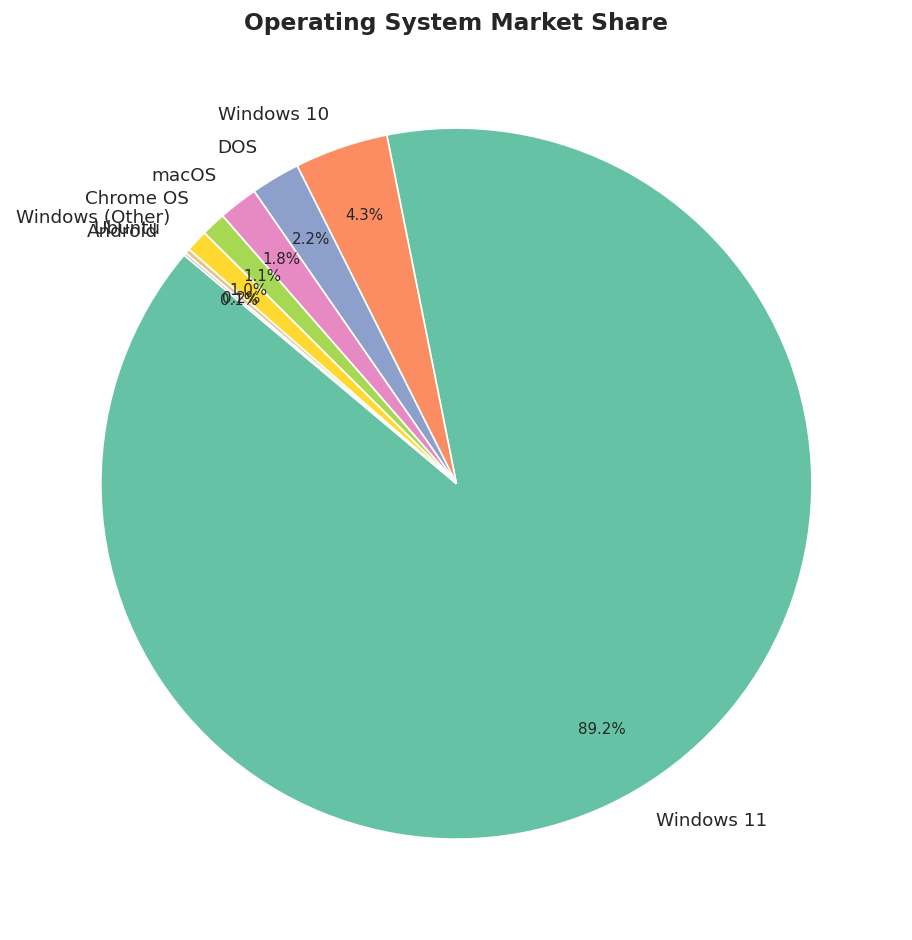

Saved: chart4_os_share.png


In [20]:
# ── Chart 4: OS Market Share ───────────────────────────────────────────────────
os_counts = df['OS_clean'].value_counts()
colors = sns.color_palette('Set2', len(os_counts))

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    os_counts.values,
    labels=os_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Operating System Market Share', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_os_share.png', bbox_inches='tight')
plt.show()
print('Saved: chart4_os_share.png')

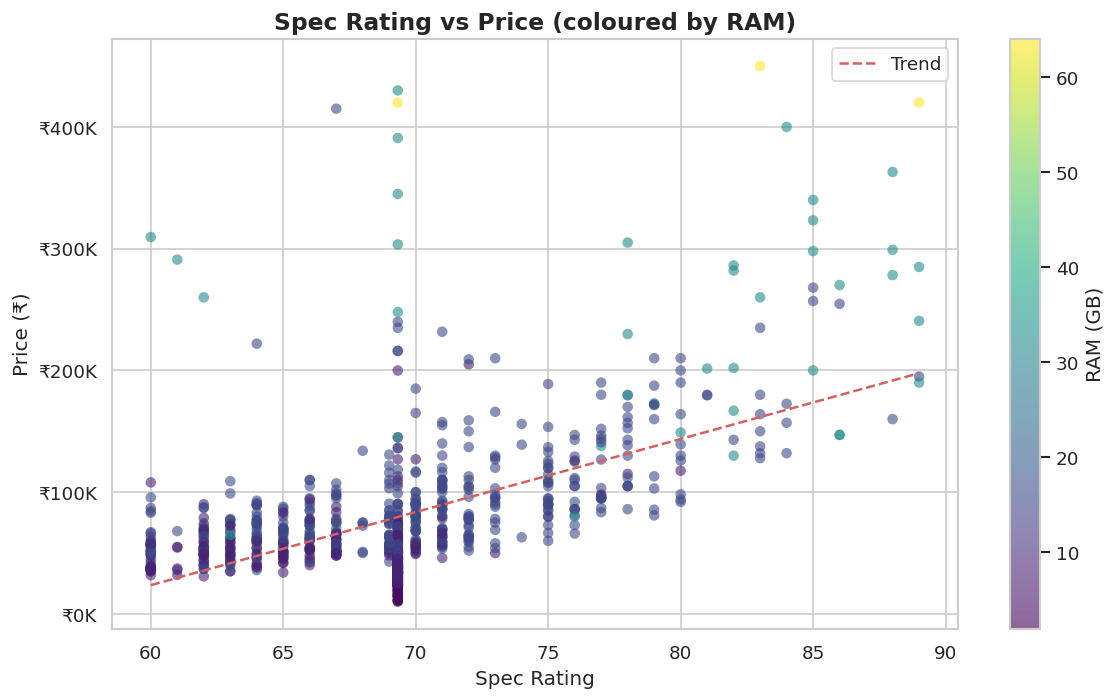

Saved: chart5_rating_vs_price.png


In [21]:
# ── Chart 5: Spec Rating vs Price (scatter) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df['spec_rating'], df['price'],
    c=df['Ram_GB'], cmap='viridis',
    alpha=0.6, s=40, edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('RAM (GB)')
ax.set_xlabel('Spec Rating')
ax.set_ylabel('Price (₹)')
ax.set_title('Spec Rating vs Price (coloured by RAM)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# Trend line
z = np.polyfit(df['spec_rating'], df['price'], 1)
p = np.poly1d(z)
xs = np.linspace(df['spec_rating'].min(), df['spec_rating'].max(), 200)
ax.plot(xs, p(xs), 'r--', linewidth=1.5, label='Trend')
ax.legend()
plt.tight_layout()
plt.savefig('chart5_rating_vs_price.png', bbox_inches='tight')
plt.show()
print('Saved: chart5_rating_vs_price.png')

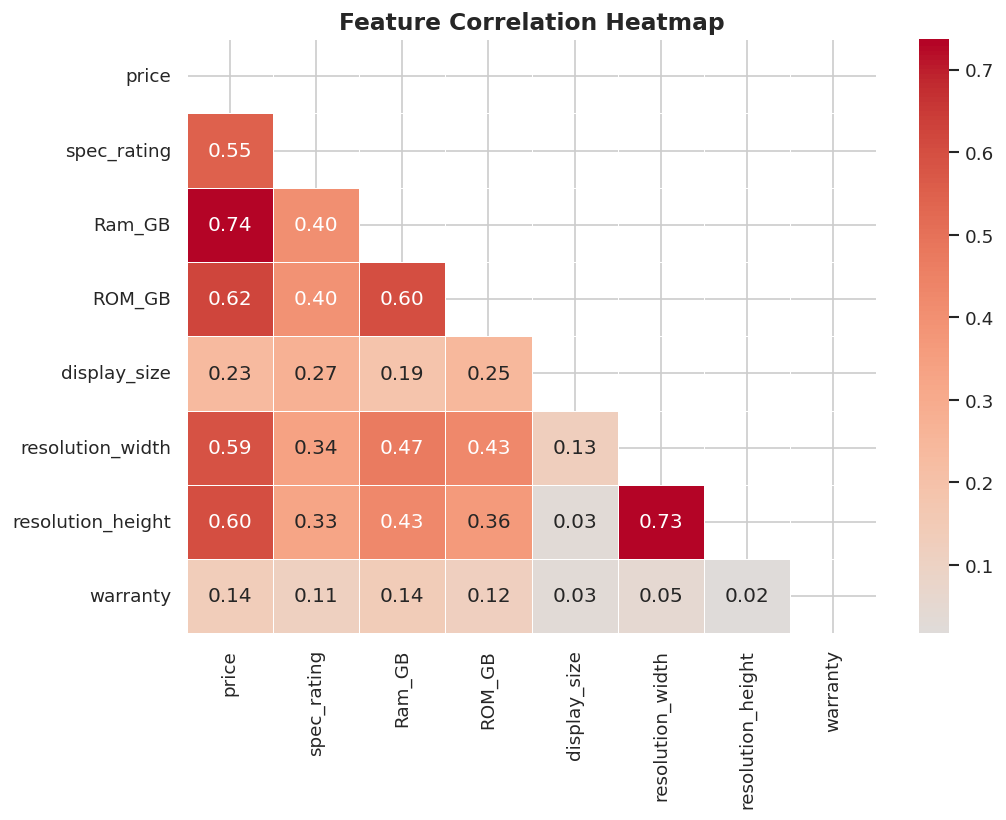

Saved: chart6_correlation_heatmap.png


In [22]:
# ── Chart 6: Correlation Heatmap ──────────────────────────────────────────────
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: chart6_correlation_heatmap.png')

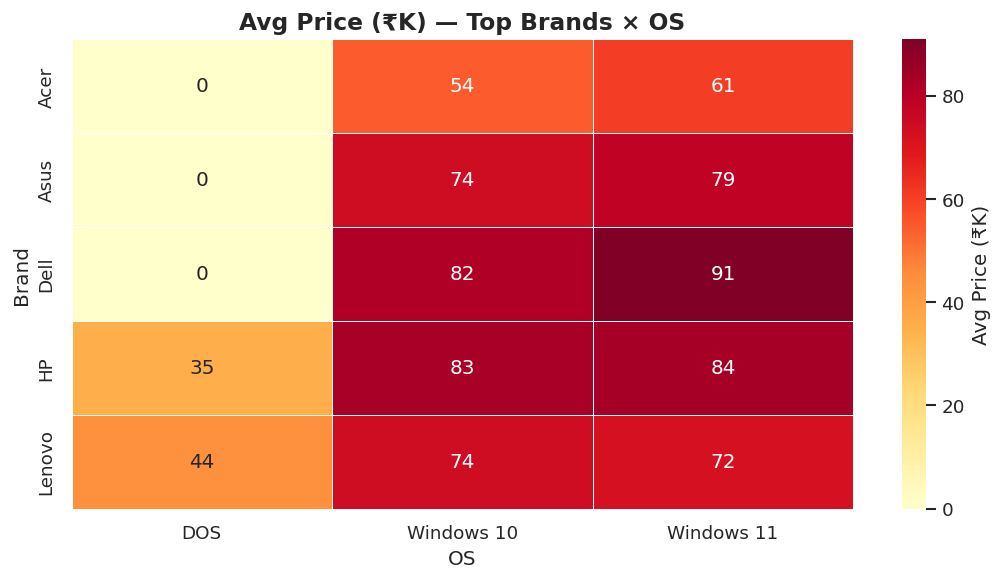

Saved: chart7_brand_os_heatmap.png


In [23]:
# ── Chart 7: Average Price by Brand × OS (heatmap) ────────────────────────────
top5_brands = df['brand'].value_counts().head(5).index.tolist()
top4_os     = df['OS_clean'].value_counts().head(4).index.tolist()

pivot = (
    df[df['brand'].isin(top5_brands) & df['OS_clean'].isin(top4_os)]
    .groupby(['brand', 'OS_clean'])['price']
    .mean()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot / 1000, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Price (₹K)'})
ax.set_title('Avg Price (₹K) — Top Brands × OS', fontsize=14, fontweight='bold')
ax.set_xlabel('OS')
ax.set_ylabel('Brand')
plt.tight_layout()
plt.savefig('chart7_brand_os_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: chart7_brand_os_heatmap.png')

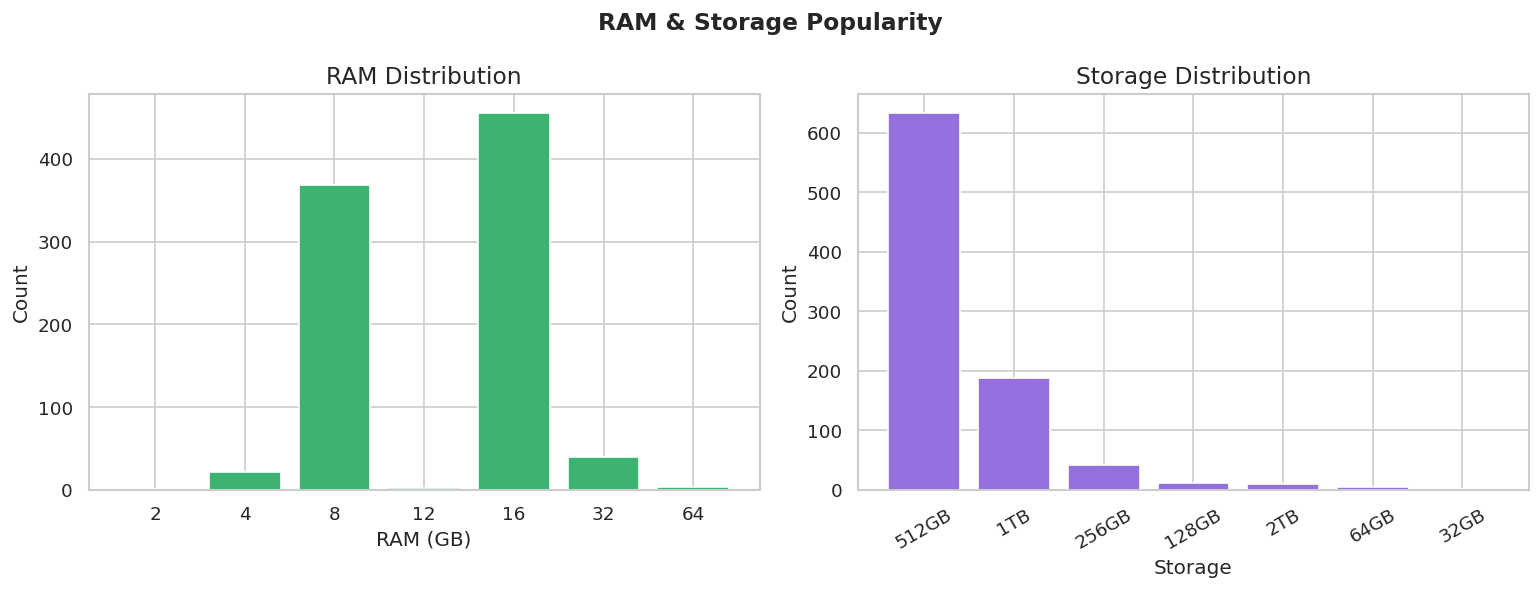

Saved: chart8_ram_storage.png


In [24]:
# ── Chart 8: RAM & Storage Popularity ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ram_vc = df['Ram_GB'].value_counts().sort_index()
axes[0].bar(ram_vc.index.astype(str), ram_vc.values, color='mediumseagreen')
axes[0].set_title('RAM Distribution')
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Count')

rom_labels = df['ROM'].value_counts().index
rom_vals   = df['ROM'].value_counts().values
axes[1].bar(rom_labels, rom_vals, color='mediumpurple')
axes[1].set_title('Storage Distribution')
axes[1].set_xlabel('Storage')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('RAM & Storage Popularity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_ram_storage.png', bbox_inches='tight')
plt.show()
print('Saved: chart8_ram_storage.png')

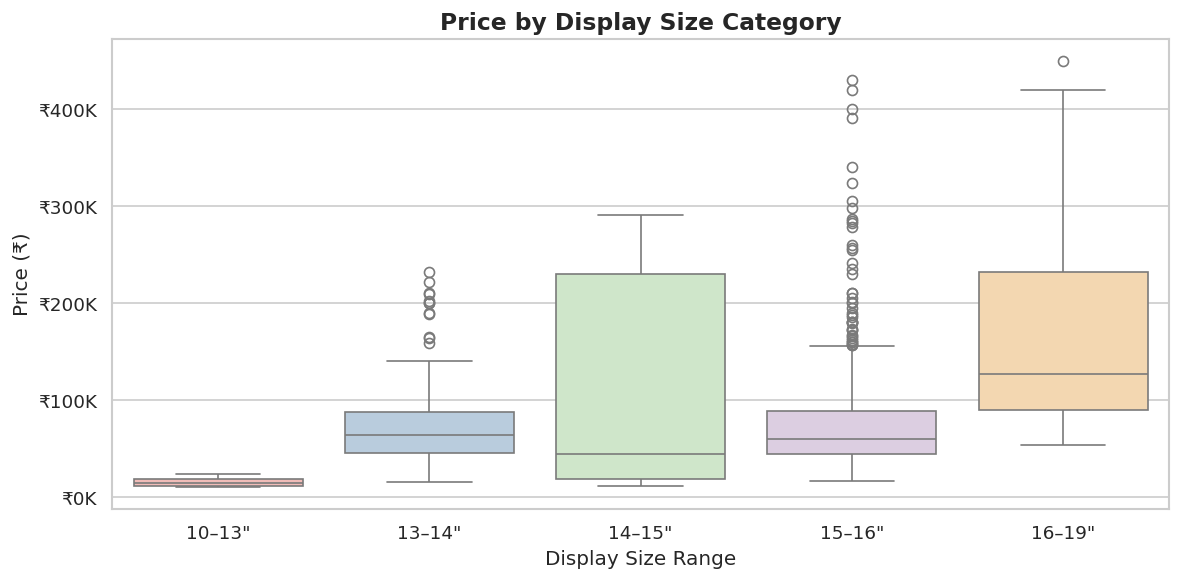

Saved: chart9_display_vs_price.png


In [25]:
# ── Chart 9: Display Size vs Price ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
display_bins = pd.cut(df['display_size'], bins=[10, 13, 14, 15, 16, 19], 
                      labels=['10–13"', '13–14"', '14–15"', '15–16"', '16–19"'])
df['display_bin'] = display_bins
sns.boxplot(data=df, x='display_bin', y='price', palette='Pastel1', ax=ax)
ax.set_title('Price by Display Size Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Display Size Range')
ax.set_ylabel('Price (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('chart9_display_vs_price.png', bbox_inches='tight')
plt.show()
print('Saved: chart9_display_vs_price.png')

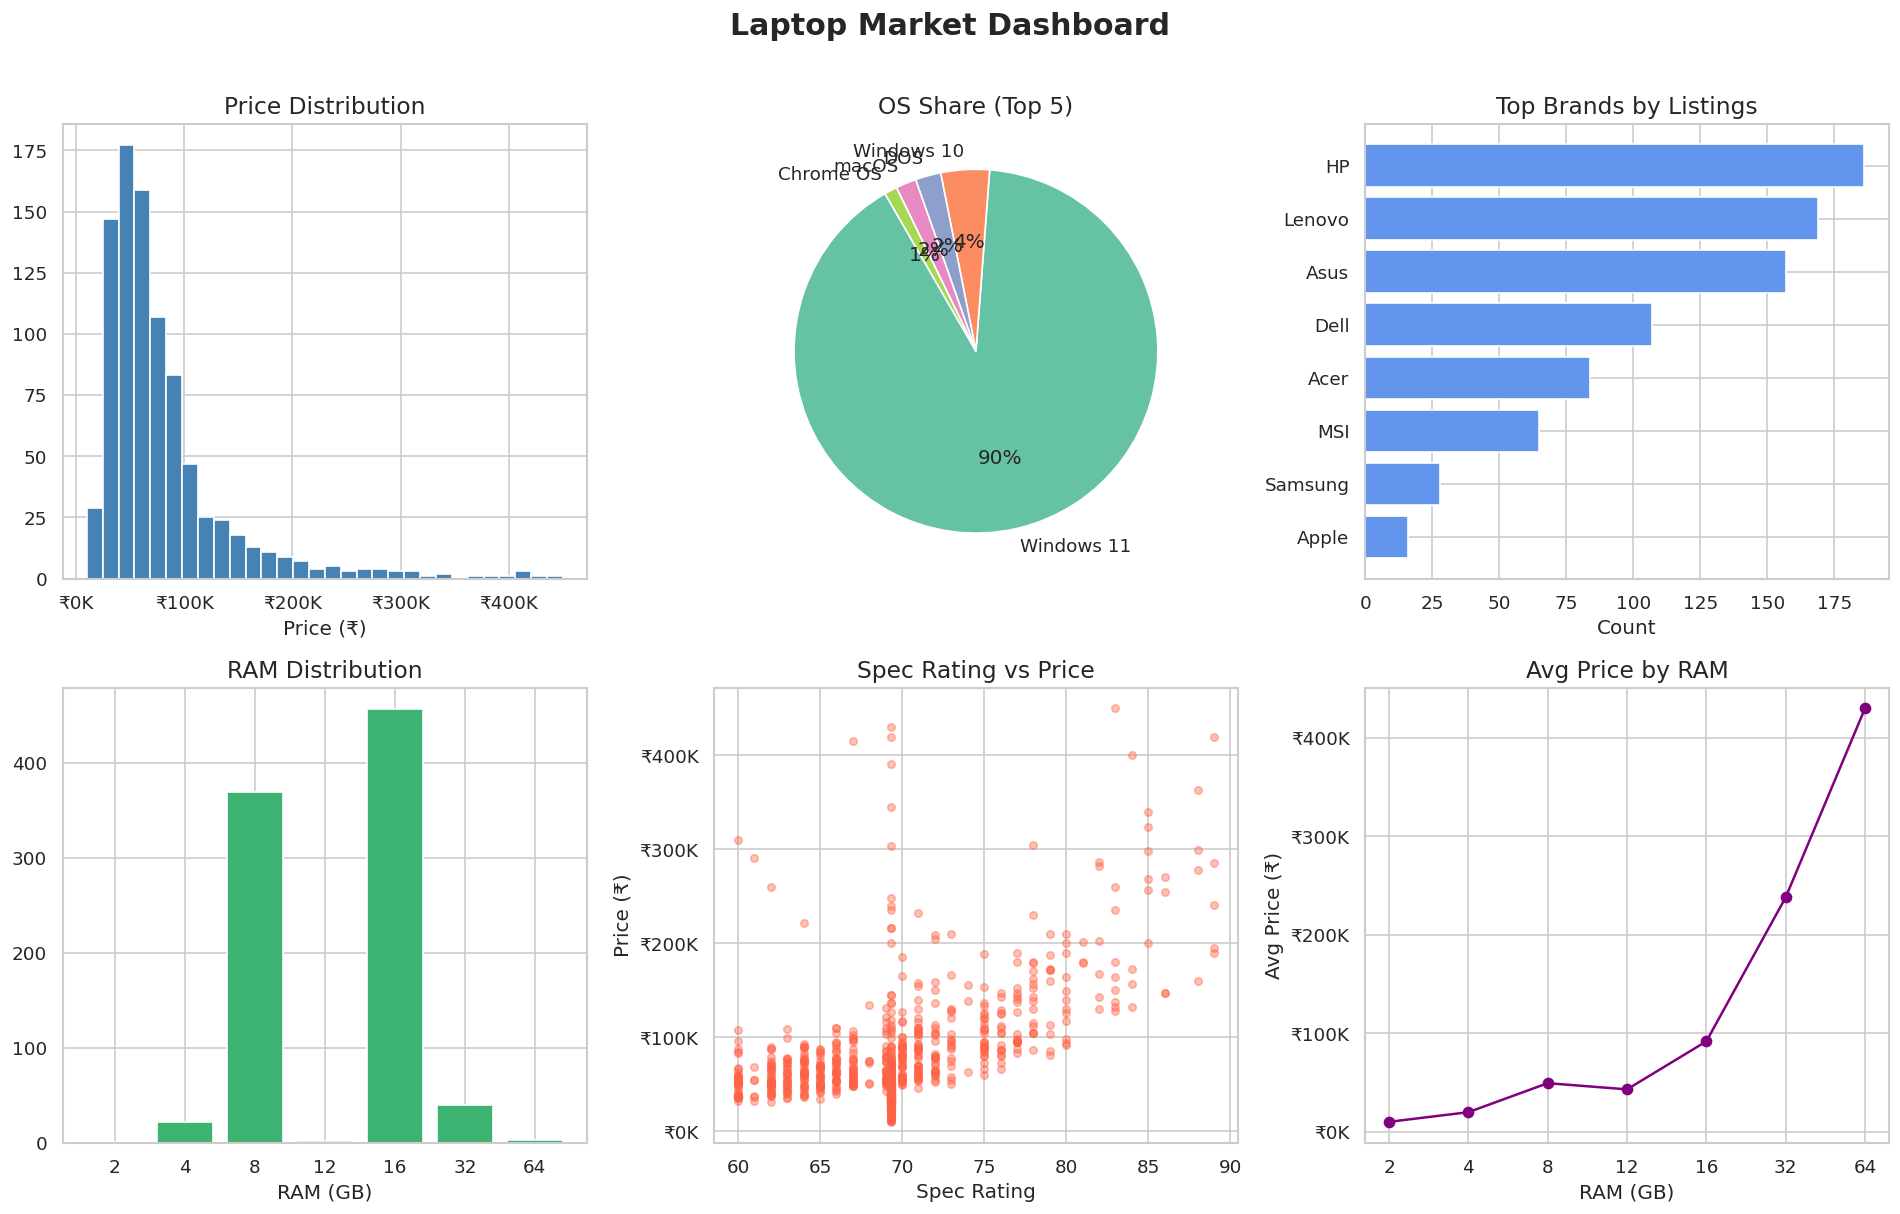

Saved: chart10_dashboard.png


In [26]:
# ── Chart 10: Dashboard Summary ───────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Laptop Market Dashboard', fontsize=18, fontweight='bold', y=1.01)

# Subplot 1 – price histogram
ax1 = fig.add_subplot(2, 3, 1)
ax1.hist(df['price'], bins=30, color='steelblue', edgecolor='white')
ax1.set_title('Price Distribution')
ax1.set_xlabel('Price (₹)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# Subplot 2 – OS pie
ax2 = fig.add_subplot(2, 3, 2)
os_top = df['OS_clean'].value_counts().head(5)
ax2.pie(os_top.values, labels=os_top.index, autopct='%1.0f%%',
        colors=sns.color_palette('Set2', 5), startangle=120)
ax2.set_title('OS Share (Top 5)')

# Subplot 3 – brand bar
ax3 = fig.add_subplot(2, 3, 3)
brand_top = df['brand'].value_counts().head(8)
ax3.barh(brand_top.index[::-1], brand_top.values[::-1], color='cornflowerblue')
ax3.set_title('Top Brands by Listings')
ax3.set_xlabel('Count')

# Subplot 4 – RAM bar
ax4 = fig.add_subplot(2, 3, 4)
ram_vc = df['Ram_GB'].value_counts().sort_index()
ax4.bar(ram_vc.index.astype(str), ram_vc.values, color='mediumseagreen')
ax4.set_title('RAM Distribution')
ax4.set_xlabel('RAM (GB)')

# Subplot 5 – spec rating vs price scatter
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(df['spec_rating'], df['price'], alpha=0.4, s=20, color='tomato')
ax5.set_title('Spec Rating vs Price')
ax5.set_xlabel('Spec Rating')
ax5.set_ylabel('Price (₹)')
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

# Subplot 6 – avg price by RAM
ax6 = fig.add_subplot(2, 3, 6)
avg_price_ram = df.groupby('Ram_GB')['price'].mean().sort_index()
ax6.plot(avg_price_ram.index.astype(str), avg_price_ram.values, 'o-', color='purple')
ax6.set_title('Avg Price by RAM')
ax6.set_xlabel('RAM (GB)')
ax6.set_ylabel('Avg Price (₹)')
ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('chart10_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: chart10_dashboard.png')

In [27]:
# Save cleaned dataset
df.to_excel('laptop_cleaned.xlsx', index=False)
print('Cleaned dataset saved: laptop_cleaned.xlsx ✅')

Cleaned dataset saved: laptop_cleaned.xlsx ✅
